# Matplotlib

## Installing Packages

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing Libraries

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

## Basics

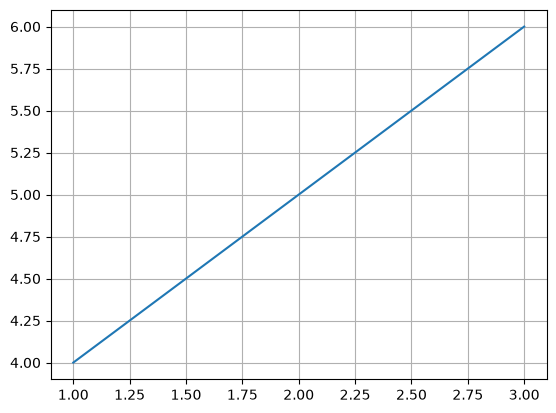

In [3]:
x = [1,2,3]
y = [4,5,6]
plt.plot(x,y) # for making graph
plt.grid() # for a grid
plt.show() # for graph view

## PyPlot API

### Univariate Variable

In [4]:
data = {
    "Salary" : [25000, 30000, 37000, 28000, 39000, 48000, 55000, 52000, 35000, 26000, 27000, 31000, 33000, 29000, 40000, 36000, 34000, 45000, 47000, 50000]
}
df = pd.DataFrame(data)
df.head(5)

,Salary
0,25000
1,30000
2,37000
3,28000
4,39000


In [5]:
df.shape

(20, 1)

#### Line Plot

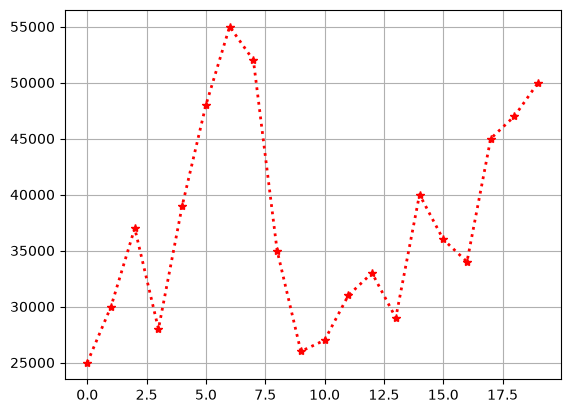

In [6]:
plt.plot(df["Salary"], color = "red", marker = "*", linestyle = ":", linewidth = "2")
plt.grid()
plt.show()

#### Histogram

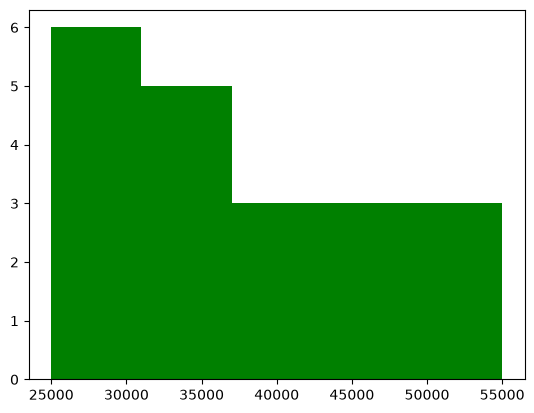

In [7]:
plt.hist(df["Salary"], color = "green", bins = 5, ) # bins are the intervals used in a histogram to group data points. Instead of plotting every individual value, the data is divided into these specific ranges (bins)
plt.show()

#### Boxplot

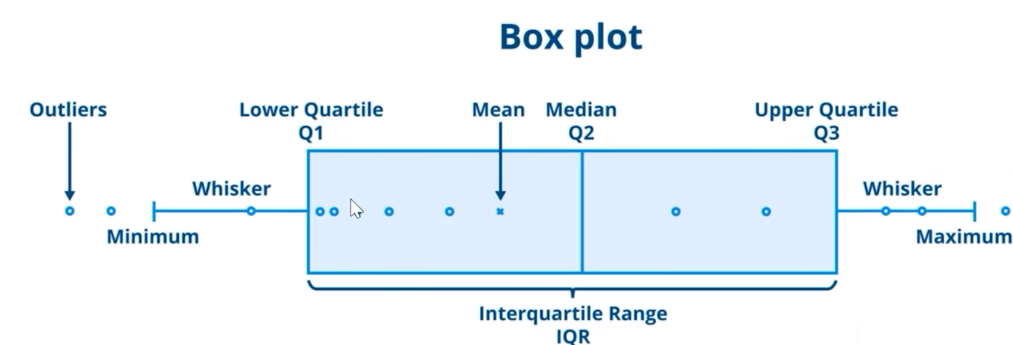

- Outliers
- Minimum
- <Interquartile Range (IQR) Starts>
- Q1 - 25%
- Mean
- Q2 - 50% (Median)
- Q3 - 75%
- <Interquartile Range (IQR) Ends>
- Maximum
- Outliers

In [8]:
df.loc[20] = 0 # Adding outlier

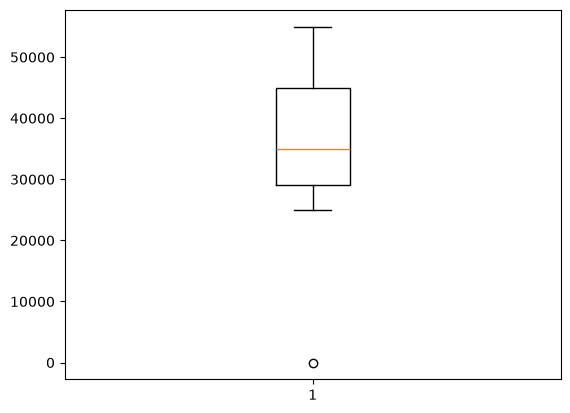

In [9]:
plt.boxplot(df["Salary"])
plt.show()

In [10]:
df.drop(index = 20, inplace = True)
df.shape

(20, 1)

### Univariate : Categorical

In [11]:
df["dept"] = ['HR', 'IT', 'Finance', 'HR', 'Finance', 'IT', 'HR', 'Finance', 'IT', 'HR'] * 2
df.head()

,Salary,dept
0,25000,HR
1,30000,IT
2,37000,Finance
3,28000,HR
4,39000,Finance


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Salary  20 non-null     int64
 1   dept    20 non-null     str  
dtypes: int64(1), str(1)
memory usage: 452.0 bytes


#### Pie Chart

In [13]:
count = df["dept"].value_counts() # Unique Values grouped by dept
count

dept
HR         8
IT         6
Finance    6
Name: count, dtype: int64

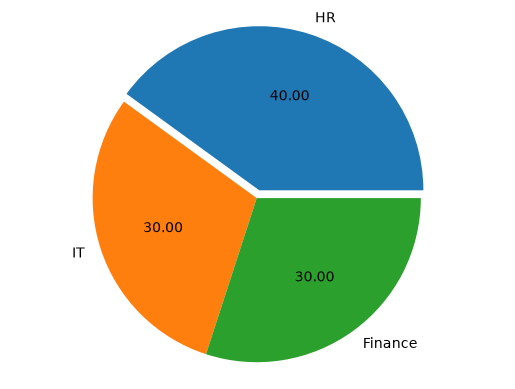

In [14]:
plt.pie(count, labels = count.index, autopct = "%1.2f", explode = [0.05, 0, 0])
plt.axis("equal") # if the pie chart is not complete circle
plt.show()

#### Countplot

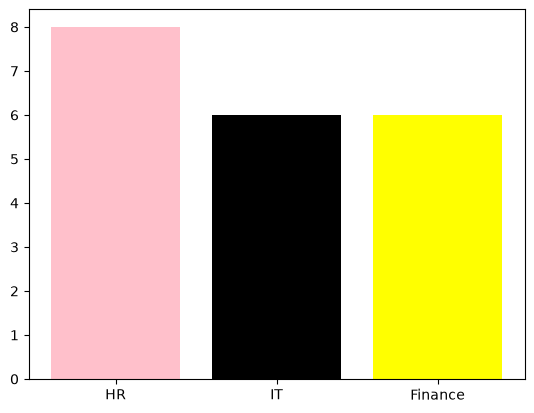

In [15]:
plt.bar(count.index, count, color=["pink", "black", "yellow" ])
plt.show()

### Bivariate

In [16]:
df["Age"] = [22, 25, 29, 24, 30, 35, 40, 36, 28, 22, 23, 25, 26, 24, 31, 29, 27, 33, 35, 38]
df.head()

,Salary,dept,Age
0,25000,HR,22
1,30000,IT,25
2,37000,Finance,29
3,28000,HR,24
4,39000,Finance,30


#### Scatterplot

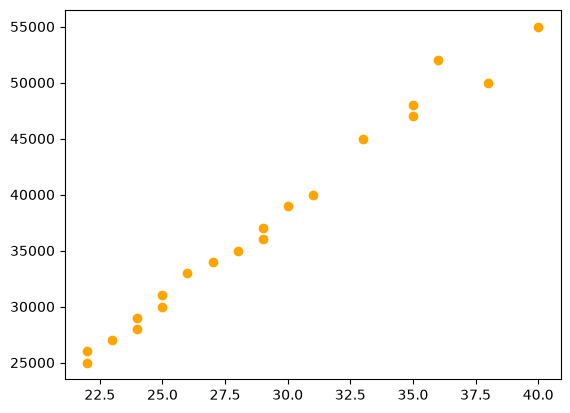

In [17]:
plt.scatter(df["Age"], df["Salary"], color = "orange")
plt.show()

#### Lineplot

In [18]:
sort_age = df.sort_values("Age") #Sorting, otherwise the graph will go back and forth

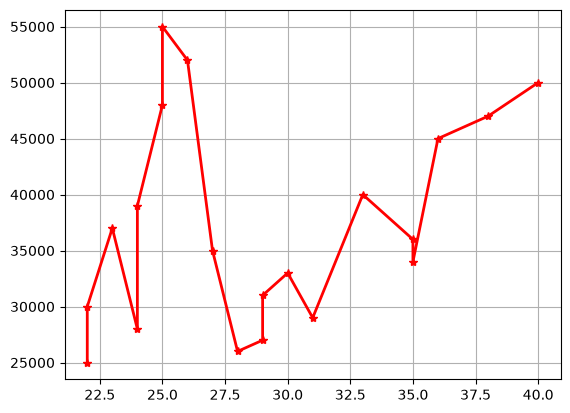

In [19]:
plt.plot(sort_age["Age"], df["Salary"], color = "red", marker = "*", linewidth = "2")
plt.grid()
plt.show()

#### Bar Chart

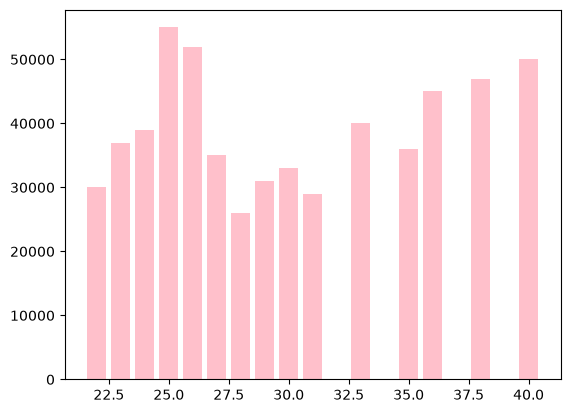

In [20]:
plt.bar(sort_age["Age"], df["Salary"], color="pink", align = "center") # alignment - edge or center
plt.show()

### Bivariate: 1 Numerical & 1 Categorical

In [21]:
hr_sal = df[df["dept"] == "HR"]["Salary"]
hr_sal

0     25000
3     28000
6     55000
9     26000
10    27000
13    29000
16    34000
19    50000
Name: Salary, dtype: int64

In [22]:
it_sal = df[df["dept"] == "IT"]["Salary"]
it_sal

1     30000
5     48000
8     35000
11    31000
15    36000
18    47000
Name: Salary, dtype: int64

In [23]:
fin_sal = df[df["dept"] == "Finance"]["Salary"]
fin_sal

2     37000
4     39000
7     52000
12    33000
14    40000
17    45000
Name: Salary, dtype: int64

#### Boxplot

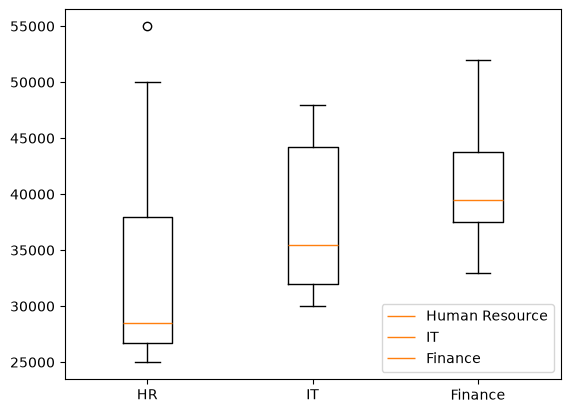

In [24]:
plt.boxplot([hr_sal, it_sal, fin_sal], tick_labels=["HR", "IT", "Finance"], label=["Human Resource", "IT", "Finance"] ) # label is used in legend

plt.legend()

plt.show()

#### Pie Chart

In [25]:
salary_by_dept = df.groupby("dept")["Salary"].sum()
salary_by_dept

dept
Finance    246000
HR         274000
IT         227000
Name: Salary, dtype: int64

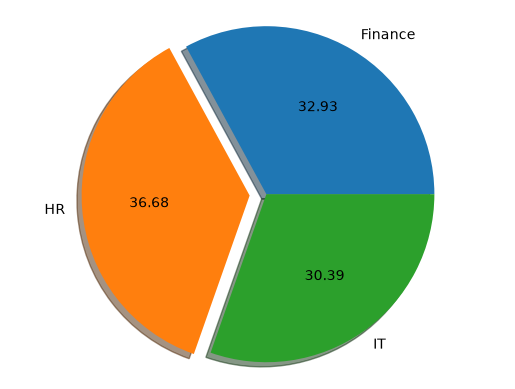

In [26]:
plt.pie(salary_by_dept, labels = salary_by_dept.index, autopct = "%1.2f", explode = [0, 0.1, 0], shadow = True)
plt.axis("equal")
plt.show()

#### Bar Plot

In [27]:
hr_mean = sum(hr_sal)/len(hr_sal)
it_mean = sum(it_sal)/len(it_sal)
fin_mean = sum(fin_sal)/len(fin_sal)

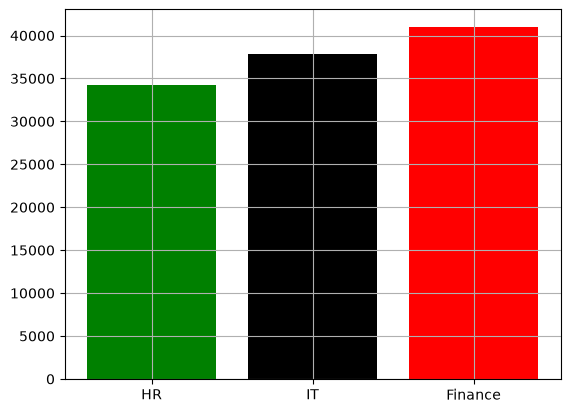

In [28]:
plt.bar(["HR", "IT", "Finance"], [hr_mean, it_mean, fin_mean], color = ["green", "black", "red"])
plt.grid()
plt.show()

### Multivariate Analysis: 3 numerical columns

In [29]:
df["experience"] =  [1, 2, 4, 1.5, 5, 8, 12, 10, 4, 1, 1.2, 2, 3, 1.8, 5.5, 4.5, 3.2, 7, 8, 10]
df.head()

,Salary,dept,Age,experience
0,25000,HR,22,1.0
1,30000,IT,25,2.0
2,37000,Finance,29,4.0
3,28000,HR,24,1.5
4,39000,Finance,30,5.0


#### Bubble Plot

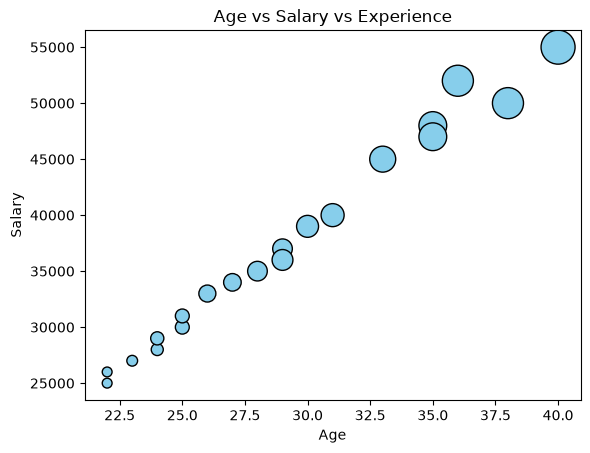

In [30]:
plt.scatter(df["Age"], df["Salary"], s = df["experience"]*50, color = "skyblue", edgecolors= "black") # s = size of bubble which is now 50 times
plt.title("Age vs Salary vs Experience")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

### Multivariate: 2 numerical & 1 categorical

#### Bubble Plot

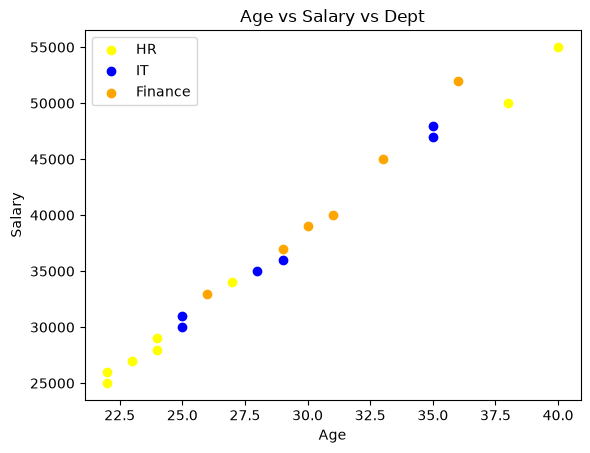

In [31]:
import matplotlib.pyplot as plt

dept_colors = {"HR": "yellow", "IT": "blue", "Finance": "orange"}

# Loop through the dictionary to plot each department separately
for dept, color in dept_colors.items():
    df_dept = df[df["dept"] == dept]
    plt.scatter(df_dept["Age"], df_dept["Salary"], c=color, label=dept)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary vs Dept")
plt.legend()
plt.show()

# Using seaborn instead of matplotlib will reduce the code my removing this loop for legend

## Object Oriented API

It allows multiple plots in one figure

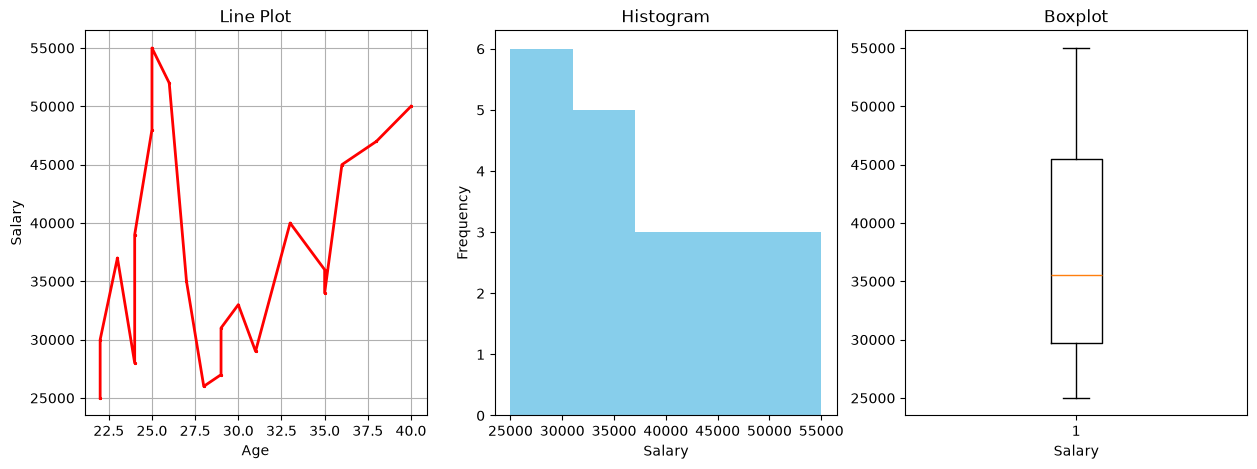

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

#Line Plot
axs[0].plot(sort_age["Age"], df["Salary"], color="red", marker="*", linewidth="2", markersize="2")
axs[0].grid()
axs[0].set_title("Line Plot")
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Salary")

# histogram:

axs[1].hist(df["Salary"], bins = 5, color = "skyblue")
axs[1].set_title("Histogram")
axs[1].set_xlabel("Salary")
axs[1].set_ylabel("Frequency")


# Boxplot:

axs[2].boxplot(df["Salary"])
axs[2].set_title("Boxplot")
axs[2].set_xlabel("Salary")

plt.show()

In [33]:
data2 = {
    'Year': [2020, 2021, 2022, 2023],
    'Sales': [100, 150, 200, 250],
    'Profit': [20, 30, 40, 50],
    'Expenses': [80, 120, 160, 200]
}
df2 = pd.DataFrame(data2)

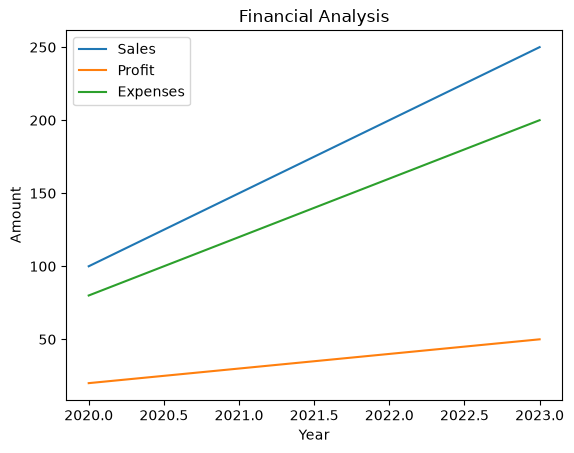

In [34]:
plt.plot(df2["Year"], df2["Sales"], label = "Sales")
plt.plot(df2["Year"], df2["Profit"], label = "Profit")
plt.plot(df2["Year"], df2["Expenses"], label = "Expenses")

plt.title("Financial Analysis")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.show()

#### 3-D Plot

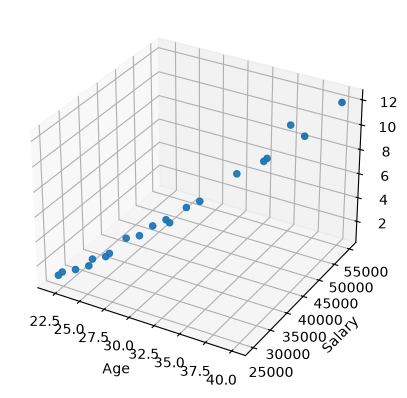

In [35]:
ax = plt.axes(projection = "3d")

ax.scatter(df["Age"], df["Salary"], df["experience"])
ax.set_xlabel("Age")
ax.set_ylabel("Salary")
ax.set_zlabel("Experience")
plt.show()

In [36]:
# You can make the above graph and move it in 3-D space by using plotly
%pip install plotly; nbformat
import plotly.express as px


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/9.9 MB 15.9 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.9 MB 15.5 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 15.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 14.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [37]:
fig = px.scatter_3d(df, x='Age', y='Salary', z='experience', title='3D Scatter Plot')
fig.show()